In [1]:
%pip uninstall sagemaker -y
%pip install "sagemaker>=2.0,<3.0" -q
!pip install tensorflow-io -q

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.3.0 which is incompatible.
sagemaker-mlops 1.11.0 requires sagemaker-core>=2.11.0, but you have sagemaker-core 1.0.78 which is incompatible.
sagemaker-serve 1.11.0 requires sagemaker-core>=2.11.0, but you have sagemaker-core 1.0.78 which is incompatible.
sagemaker-studio-analytics-extension 0.3.0 requires sparkmagic==0.22.0, but you have 

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install pydicom opencv-python-headless --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-featu

#### imports

In [3]:
import sagemaker
from sagemaker.feature_store.feature_group import FeatureGroup
import boto3
import pydicom
import tensorflow_io as tfio

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


2026-06-10 14:13:30.454311: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/opt/conda/lib/python3.12/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.12/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.12/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl5mutex6unlockEv']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.12/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.12/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.12/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZNK10tensorflow4data11DatasetBase8FinalizeEPNS_15OpKernelContextESt8functionIFN4absl12lts_202

In [27]:
import sys
sys.path.insert(0, 'FinalProject/')
from config import BUCKET_NAME, IMG_SIZE
from img_preprocessing import load_image_from_s3

In [5]:
import awswrangler as wr

df_meta = wr.athena.read_sql_query(
    "SELECT * FROM pneumonia_db.image_metadata",
    database="pneumonia_db"
)


print(f"Total images to process: {len(df_meta)}")

2026-06-10 14:13:42,277	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1908387840 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.63gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-06-10 14:13:44,456	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Total images to process: 32540


In [6]:
# This will show you the S3 LOCATION the table is registered with
table_info = wr.catalog.get_table_types(
    database="pneumonia_db",
    table="image_metadata"
)
print(table_info)

{'image_id': 'string', 'raw_s3_key': 'string', 'preprocessed_s3_key': 'string', 'label': 'string', 'label_int': 'tinyint', 'source': 'string', 'file_type': 'string', 'pixel_mean': 'double', 'pixel_std': 'double', 'img_height': 'int', 'img_width': 'int', 'event_time': 'string'}


### Grab Small Subset of data for initial dev

In [7]:
subset_df = df_meta.sample(1000)

In [8]:
subset_df['full_prepro_s3_path'] = "s3://" + BUCKET_NAME + "/" + subset_df['preprocessed_s3_key']

In [9]:
subset_df.label_int.value_counts()

label_int
0    697
1    303
Name: count, dtype: Int64

#### split into train, test, val, and production

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
split_1, split_2 = train_test_split(subset_df, test_size=.5)

In [12]:
split_1 = split_1.reset_index(drop=True)
split_2 = split_2.reset_index(drop=True)

In [13]:
train_df, test_df = train_test_split(split_1, train_size=.8)
prod_df, val_df = train_test_split(split_2, train_size=.8)

In [14]:
len(test_df)

100

#### build tensorflow datasets

In [15]:
import tensorflow as tf

In [16]:
train_df.head(2)

,image_id,raw_s3_key,preprocessed_s3_key,label,label_int,source,file_type,pixel_mean,pixel_std,img_height,img_width,event_time,full_prepro_s3_path
94,f553ad13-ccec-4c78-919f-262555295471,raw-images/rsna-pneumonia/stage_2_train_images...,preprocessed-images/NORMAL/f553ad13-ccec-4c78-...,NORMAL,0,rsna,dcm,143.4016,55.5078,512,512,2026-06-07T22:43:40Z,s3://pneumonia-data-set-group-4/preprocessed-i...
453,33ef7198-c976-4bb9-82ba-9ed9a73350ac,raw-images/rsna-pneumonia/stage_2_train_images...,preprocessed-images/NORMAL/33ef7198-c976-4bb9-...,NORMAL,0,rsna,dcm,127.7651,65.8316,512,512,2026-06-07T21:48:29Z,s3://pneumonia-data-set-group-4/preprocessed-i...


In [17]:
train_df.file_type.unique()

<StringArray>
['dcm', 'jpeg']
Length: 2, dtype: string

In [18]:
label_map = {}
for dic in subset_df.to_dict(orient='records'):
    label_map[dic['preprocessed_s3_key']] = dic['label_int']

In [19]:
import boto3

s3 = boto3.client("s3")

In [20]:
import matplotlib.pyplot as plt
import numpy as np

In [32]:
def load_sample(s3_path, label):
    def _read_and_decode(path_bytes):
        path = path_bytes.decode("utf-8")
        bucket, key = path.replace("s3://", "").split("/", 1)
        obj = s3.get_object(Bucket=bucket, Key=key)
        img = Image.open(BytesIO(obj["Body"].read())).convert("L")  # L = grayscale
        arr = np.array(img, dtype=np.float32)  # (512, 512)
        arr = arr[:, :, np.newaxis]             # (512, 512, 1)
        return arr

    image = tf.numpy_function(_read_and_decode, [s3_path], tf.float32)
    #image.set_shape([512, 512, 1])
    return image, label

In [33]:
paths = train_df.full_prepro_s3_path.values
labels = train_df.label_int.values.astype(int)
train_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
train_ds = train_ds.map(load_sample)

In [34]:
import boto3
import pydicom
import matplotlib.pyplot as plt
from io import BytesIO

s3 = boto3.client("s3")
bucket = BUCKET_NAME
key = train_df["full_prepro_s3_path"].iloc[0].replace(f"s3://{bucket}/", "")

obj = s3.get_object(Bucket=bucket, Key=key)
img_bytes = obj["Body"].read()

# Check what PIL sees
from PIL import Image
img = Image.open(BytesIO(img_bytes))
print(img.size)   # (W, H)
print(img.mode)   # L = grayscale, RGB, etc.

(512, 512)
L


(512, 512, 1)


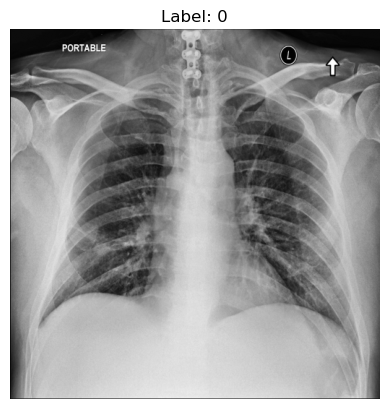

2026-06-10 14:31:00.396932: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [35]:
for image, label in train_ds.take(1):
    #print(images.shape)
    print(image.shape)
   # label = labels.numpy()[0]  # index into numpy array instead
    
    plt.imshow(image.numpy(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

In [ ]:

train_ds = tf.data.Dataset(train_df.preprocessed_s3_key.tolist())
train_img_ds = train_ds.map(parse_img)

In [ ]:
train_df.file_type.unique()

In [ ]:
train_df.full_prepro_s3_path.iloc[-4]

### Building the Model

In [26]:
import keras
from keras import layers

In [40]:
model_layers = [
    layers.Input(shape=(*IMG_SIZE, 1)), 
    layers.Conv2D(32, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    
    layers.Conv2D(128, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.GlobalAveragePooling2D(), # this is the equivalent of flattening
    layers.Dense(128, activation='relu'),
    layers.Dropout(.8),
    layers.Dense(16, activation='relu'),
    layers.Dropout(.8),
    layers.Dense(1, activation='sigmoid')
]
model = keras.Sequential(model_layers)